In [2]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize


In [24]:
current_holdings = {
    'ETH-USD': 588,
    'SOL-USD': 50,
    'AMD': 106,
    'URA': 147,
    'PANW': 4,
    'TX': 2,
    'EWJ': 324,
    'PAM': 196,
    'HSBC': 179,
    'FSLR' : 190
}

candidates = []

all_tickers = list(current_holdings.keys())+candidates

print(f"Downloading data for: {all_tickers}")
raw_data = yf.download(all_tickers, start="2024-01-01", end="2026-05-02", group_by='column', auto_adjust = False)

try:
    if 'Adj Close' in raw_data.columns:
        data = raw_data['Adj Close']
    else:
        data = raw_data
    
    data = data.ffill().dropna()

    print("\nSuccess! Data shape:", data.shape)
    print(data.head())

except KeyError as e:
    print(f"\nStructure Error: {e}")
    print("Columns are:", raw_data.columns)

[*********************100%***********************]  10 of 10 completed


Success! Data shape: (767, 10)
Ticker             AMD      ETH-USD        EWJ        FSLR       HSBC  \
Date                                                                    
2024-01-02  138.580002  2355.836426  59.401604  172.160004  34.477882   
2024-01-03  135.320007  2210.761963  59.074501  167.419998  34.374756   
2024-01-04  136.009995  2269.038086  58.934315  166.309998  34.641163   
2024-01-05  138.580002  2268.647217  59.373566  166.869995  35.010693   
2024-01-06  138.580002  2241.624756  59.373566  166.869995  35.010693   

Ticker            PAM        PANW     SOL-USD         TX        URA  
Date                                                                 
2024-01-02  48.220001  144.460007  106.611221  36.064842  25.189423  
2024-01-03  48.490002  143.235001   98.594437  35.735641  24.910883  
2024-01-04  47.740002  141.649994  105.077538  35.952217  25.254417  
2024-01-05  48.169998  141.464996   99.978790  35.250500  25.031582  
2024-01-06  48.169998  141.464996   

In [25]:
log_returns = np.log(data/data.shift(1))
log_returns = log_returns.dropna()

print("Log Returns Shape", log_returns.shape)
log_returns.head()

Log Returns Shape (766, 10)


Ticker,AMD,ETH-USD,EWJ,FSLR,HSBC,PAM,PANW,SOL-USD,TX,URA
Date,,,,,,,,,,
2024-01-03,-0.023805,-0.063559,-0.005522,-0.027919,-0.002996,0.005584,-0.008516,-0.078174,-0.009170,-0.011119
2024-01-04,0.005086,0.026019,-0.002376,-0.006652,0.007720,-0.015588,-0.011127,0.063684,0.006042,0.013696
2024-01-05,0.018719,-0.000172,0.007426,0.003362,0.010611,0.008967,-0.001307,-0.049740,-0.019711,-0.008863
2024-01-06,0.000000,-0.011983,0.000000,0.000000,0.000000,0.000000,0.000000,-0.063178,0.000000,0.000000
2024-01-07,0.000000,-0.008404,0.000000,0.000000,0.000000,0.000000,0.000000,-0.050043,0.000000,0.000000


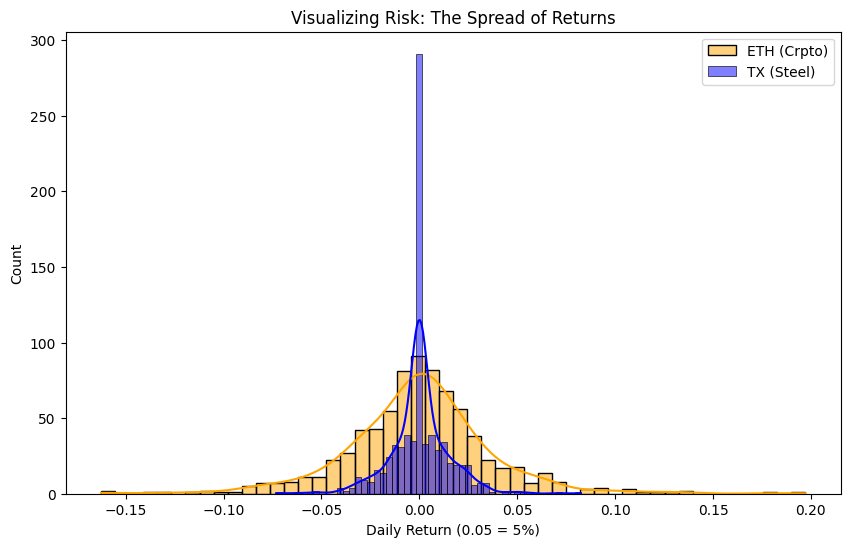

In [26]:
plt.figure(figsize=(10, 6))

sns.histplot(log_returns['ETH-USD'],bins=50,kde=True, color='orange', label='ETH (Crpto)', alpha=0.5)

sns.histplot(log_returns['TX'],bins=50,kde=True, color='blue', label='TX (Steel)', alpha=0.5)

plt.title("Visualizing Risk: The Spread of Returns")
plt.xlabel("Daily Return (0.05 = 5%)")
plt.legend()
plt.show()

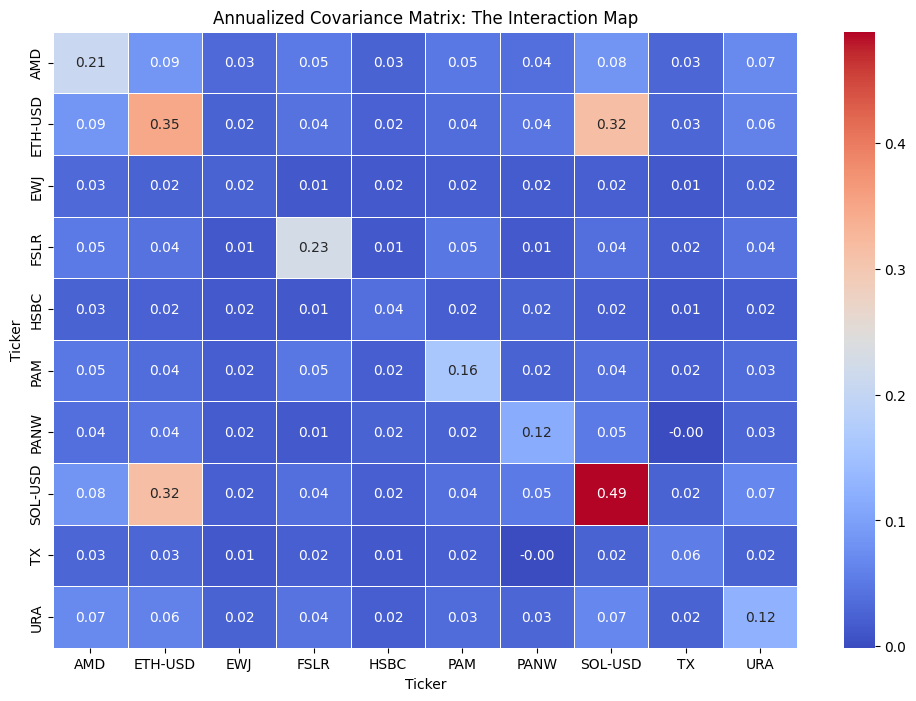


Covariance Matrix (Annualized)


Ticker,AMD,ETH-USD,EWJ,FSLR,HSBC,PAM,PANW,SOL-USD,TX,URA
Ticker,,,,,,,,,,
AMD,0.208947,0.085141,0.032191,0.051462,0.025323,0.048775,0.038549,0.084035,0.029376,0.071530
ETH-USD,0.085141,0.347371,0.023949,0.041836,0.022130,0.036095,0.044967,0.316240,0.027723,0.061363
EWJ,0.032191,0.023949,0.024269,0.013907,0.015911,0.019179,0.016644,0.021100,0.013321,0.024075
FSLR,0.051462,0.041836,0.013907,0.226035,0.013206,0.048086,0.014297,0.038411,0.020062,0.043790
HSBC,0.025323,0.022130,0.015911,0.013206,0.038040,0.018852,0.024738,0.021361,0.013152,0.018067


In [27]:
covar_matrix= log_returns.cov() * 252

plt.figure(figsize=(12,8))
sns.heatmap(covar_matrix, annot=True, cmap='coolwarm', fmt=".2f",linewidths=.5)
plt.title("Annualized Covariance Matrix: The Interaction Map")
plt.show()
print("\nCovariance Matrix (Annualized)")
covar_matrix.head()

In [28]:
valid_tickers = [t for t in current_holdings.keys() if t in data.columns]
current_values = np.array([current_holdings[t]for t in valid_tickers])
current_total = np.sum(current_values)
current_weights = current_values / current_total

full_currnet_weights = np.array([current_holdings.get(ticker,0)/current_total for ticker in data.columns])

baseline_return = np.sum(log_returns.mean() * full_currnet_weights)*252

baseline_variance = np.dot(full_currnet_weights.T,np.dot(covar_matrix, full_currnet_weights))
baseline_volatility = np.sqrt(baseline_variance)

print("---SATTUS QUO (Current Portfolio)---")
print(f"Total Invested: ${current_total:.0f}")
print(f"Annual Volatility (Risk): {baseline_volatility:.2%}")
print(f"Naive Annual Return: {baseline_return:.2%}")
print(f"Sharpe Ratio: {baseline_return/baseline_volatility:.2f}")

def portfolio_volatility(weights, covar_matrix):
    return np.sqrt(np.dot(weights.T,np.dot(covar_matrix, weights)))

num_assets = len(data.columns)
initial_guess = [1/num_assets]*num_assets
bounds = tuple((0,1)for _ in range(num_assets))
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x)-1})

result = minimize(portfolio_volatility,initial_guess,args=(covar_matrix),method = 'SLSQP',bounds=bounds,constraints = constraints)

min_vol_weights = result.x
min_volatility = result.fun

print("\n---OPTIMIZED MODEL ( Minimun Variance) ---")
print(f"Minimun Possible Volatility: {min_volatility:.2%}")
print(f"Risk Reduction: {baseline_volatility-min_volatility:.2%}")

comparison_df = pd.DataFrame({'Asset':data.columns,'Your Current Allocation': full_currnet_weights, 'Optimized Allocation': min_vol_weights})

comparison_df = comparison_df[comparison_df['Optimized Allocation']>0.001]
comparison_df['Your Current Allocation']= comparison_df['Your Current Allocation'].apply(lambda x: f"{x:.1%}")
comparison_df['Optimized Allocation'] = comparison_df['Optimized Allocation'].apply(lambda x: f"{x:.1%}")

print("\nAlloction Comparison:")
print(comparison_df)

---SATTUS QUO (Current Portfolio)---
Total Invested: $1786
Annual Volatility (Risk): 27.98%
Naive Annual Return: 8.97%
Sharpe Ratio: 0.32

---OPTIMIZED MODEL ( Minimun Variance) ---
Minimun Possible Volatility: 14.18%
Risk Reduction: 13.80%

Alloction Comparison:
  Asset Your Current Allocation Optimized Allocation
2   EWJ                   18.1%                55.8%
3  FSLR                   10.6%                 2.5%
4  HSBC                   10.0%                19.4%
6  PANW                    0.2%                 5.1%
8    TX                    0.1%                17.3%


Running Monte Carlo Simulation...


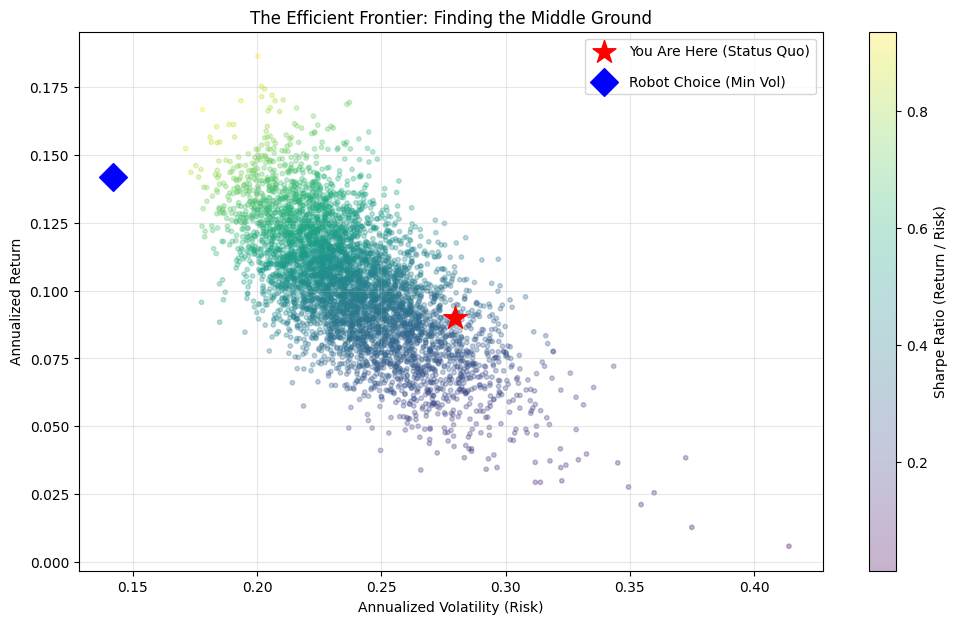

In [29]:


num_portfolios = 5000
results = np.zeros((3, num_portfolios)) 
all_weights = [] 

print("Running Monte Carlo Simulation...")

for i in range(num_portfolios):
    
    weights = np.random.random(len(all_tickers))
    weights /= np.sum(weights) 
    all_weights.append(weights)
    
    
    
    port_return = np.sum(log_returns.mean() * weights) * 252
    
    port_std = np.sqrt(np.dot(weights.T, np.dot(covar_matrix, weights)))
    
    
    results[0,i] = port_return
    results[1,i] = port_std
    results[2,i] = port_return / port_std 


plt.figure(figsize=(12, 7))


plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis', marker='o', s=10, alpha=0.3)
plt.colorbar(label='Sharpe Ratio (Return / Risk)')


plt.scatter(baseline_volatility, baseline_return, marker='*', color='red', s=300, label='You Are Here (Status Quo)')


plt.scatter(min_volatility, result.fun, marker='D', color='blue', s=200, label='Robot Choice (Min Vol)')

plt.title('The Efficient Frontier: Finding the Middle Ground')
plt.xlabel('Annualized Volatility (Risk)')
plt.ylabel('Annualized Return')
plt.legend(labelspacing=1.2)
plt.grid(True, alpha=0.3)
plt.show()